# Major Project: Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 2026–2027**  
**Major Project – Seasonal Agriculture Performance Analysis**

### Project focus
This notebook performs a focused data-analytics investigation of how agricultural performance changes across seasons. It covers data understanding, cleaning and preparation, seasonal comparisons, environmental/resource relationships, economic outcomes, regional/crop consistency, unusual patterns, statistical analysis, visualization, conclusions, and data-driven recommendations.

> **Important:** The analytical questions below were developed after inspecting the supplied dataset, in line with the project brief. The results are generated from the dataset itself; no values are manually entered into the analysis.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. Therefore, agricultural performance may differ from one season to another.

The purpose of this project is to analyze the supplied agricultural dataset and investigate seasonal differences by identifying meaningful patterns, trends, relationships and variations in the available data.

## 2. Project Objectives

This notebook addresses the project objectives by:

- exploring and understanding the dataset;
- cleaning and preparing the data;
- examining how agricultural performance varies across seasons;
- identifying seasonal patterns and trends;
- investigating relationships between seasonal conditions and agricultural outcomes;
- comparing relevant groups within seasons;
- identifying significant differences and unusual patterns;
- applying suitable statistical and visualization techniques;
- interpreting findings using evidence from the dataset; and
- developing conclusions and data-driven recommendations.

## 3. Key Questions Addressed

The project brief asks students to develop their own specific analytical questions after exploring the dataset. Based on the columns available in this dataset, the notebook investigates:

1. How is agricultural performance distributed across the seasons?
2. Which season performs best on yield, production, revenue and profit?
3. Which environmental characteristics change across seasons?
4. How do resource usage and water efficiency differ by season?
5. How do crop performances differ across seasons?
6. Are environmental conditions associated with yield?
7. Which farming/resource variables are associated with yield and profit?
8. How do economic outcomes vary across seasons and crops?
9. Are seasonal patterns consistent across states?
10. What unusual observations or outliers are present, and what seasonal patterns do they reveal?
11. What evidence-based conclusions and recommendations can support better seasonal agricultural planning?

## 4. Technology Used

- Python
- Pandas and NumPy for data handling and analysis
- Matplotlib and Seaborn for visualization
- SciPy for statistical testing
- Jupyter Notebook / Google Colab as the analysis environment

In [1]:
# Import required libraries
import io
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## 5. Load the Dataset

### Google Colab upload
Run the next cell and select the supplied CSV file from your computer. The code automatically detects the uploaded CSV, so the exact local filename does not have to match the notebook filename.

In [2]:
# Upload the CSV file in Google Colab
from google.colab import files
uploaded = files.upload()

csv_files = [name for name in uploaded.keys() if name.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError('No CSV file was uploaded. Please upload the seasonal agriculture performance CSV.')

DATA_FILE = csv_files[0]
df = pd.read_csv(DATA_FILE)
print(f'Dataset loaded from: {DATA_FILE}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

Saving seasonal_agriculture_performance_dataset (3).csv to seasonal_agriculture_performance_dataset (3).csv
Dataset loaded from: seasonal_agriculture_performance_dataset (3).csv
Rows: 4,000 | Columns: 28


## 6. Initial Dataset Understanding

In [3]:
print('Dataset shape:', df.shape)
print('\nColumn names:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2}. {col}')

print('\nFirst 5 rows:')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('Data Type'))

Dataset shape: (4000, 28)

Column names:
 1. Farm_ID
 2. State
 3. District
 4. Crop
 5. Season
 6. Farm_Area_Hectares
 7. Rainfall_mm
 8. Avg_Temperature_C
 9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct

First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30



Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [4]:
# Numerical summary
print('Numerical descriptive statistics:')
display(df.describe().T)

print('Categorical columns and number of unique values:')
cat_info = pd.DataFrame({
    'Unique_Values': df.select_dtypes(include='object').nunique(),
    'Missing_Values': df.select_dtypes(include='object').isna().sum()
})
display(cat_info)

Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


Categorical columns and number of unique values:


,Unique_Values,Missing_Values
Farm_ID,4000,0
State,8,0
District,10,0
Crop,8,0
Season,3,0
Irrigation_Method,4,0


In [5]:
# Important category distributions
for col in ['Season', 'State', 'District', 'Crop', 'Irrigation_Method']:
    if col in df.columns:
        print(f'\n{col} distribution:')
        display(df[col].value_counts(dropna=False).to_frame('Count'))


Season distribution:


,Count
Season,
Kharif,1779
Rabi,1627
Zaid,594



State distribution:


,Count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484



District distribution:


,Count
District,
Ludhiana,427
Warangal,422
Nalgonda,415
Erode,403
Rajkot,401
Krishna,393
Indore,392
Guntur,390
Raichur,386



Crop distribution:


,Count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



Irrigation_Method distribution:


,Count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


## 7. Data Quality Assessment and Cleaning

The project brief requires the data to be cleaned and prepared before analysis. The following checks identify missing values, duplicates, data-type issues, impossible values and extreme observations. Missing numerical observations are **not automatically replaced with arbitrary values**; the analysis uses appropriate valid observations for each calculation.

In [6]:
# Missing values and duplicate records
quality = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percent': (df.isna().mean() * 100).round(2),
    'Data_Type': df.dtypes.astype(str),
    'Unique_Count': df.nunique(dropna=True)
}).sort_values('Missing_Count', ascending=False)

display(quality)
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate Farm_ID values:', df['Farm_ID'].duplicated().sum())

,Missing_Count,Missing_Percent,Data_Type,Unique_Count
Rainfall_mm,48,1.20,float64,3256
Soil_Moisture_pct,40,1.00,float64,343
Yield_Tonnes_Ha,32,0.80,float64,738
Farm_ID,0,0.00,object,4000
Crop,0,0.00,object,8
District,0,0.00,object,10
Farm_Area_Hectares,0,0.00,float64,1370
Season,0,0.00,object,3
Avg_Temperature_C,0,0.00,float64,204
Humidity_pct,0,0.00,float64,573


Duplicate rows: 0
Duplicate Farm_ID values: 0


In [7]:
# Standardize text columns without changing their meaning
text_cols = df.select_dtypes(include='object').columns.tolist()
for col in text_cols:
    df[col] = df[col].astype('string').str.strip()

# Check for empty strings created by formatting
empty_counts = {c: int((df[c] == '').sum()) for c in text_cols}
print('Empty-string counts:', empty_counts)

# Domain/range checks based on the meaning of the supplied columns
range_rules = {
    'Farm_Area_Hectares': (0, np.inf),
    'Rainfall_mm': (0, np.inf),
    'Humidity_pct': (0, 100),
    'Soil_Moisture_pct': (0, 100),
    'Seed_Quality_Score': (0, 1),
    'Yield_Tonnes_Ha': (0, np.inf),
    'Production_Tonnes': (0, np.inf),
    'Market_Price_INR_Tonne': (0, np.inf),
    'Total_Cost_INR': (0, np.inf),
    'Revenue_INR': (0, np.inf),
    'Water_Used_m3': (0, np.inf),
    'Water_Efficiency_t_per_1000m3': (0, np.inf),
    'Disease_Pest_Risk_pct': (0, 100),
    'Soil_pH': (0, 14)
}
range_report = []
for col, (lo, hi) in range_rules.items():
    if col in df.columns:
        invalid = ((df[col] < lo) | (df[col] > hi)).sum()
        range_report.append([col, int(invalid)])
range_report = pd.DataFrame(range_report, columns=['Column', 'Out_of_Range_Count'])
display(range_report)

# Work on a cleaned copy. There are no duplicate records in the supplied dataset.
clean_df = df.drop_duplicates().copy()
print('Rows after duplicate removal:', len(clean_df))
print('No arbitrary row deletion was performed for missing numerical values; analyses use valid observations.')

Empty-string counts: {'Farm_ID': 0, 'State': 0, 'District': 0, 'Crop': 0, 'Season': 0, 'Irrigation_Method': 0}


,Column,Out_of_Range_Count
0,Farm_Area_Hectares,0
1,Rainfall_mm,0
2,Humidity_pct,0
3,Soil_Moisture_pct,0
4,Seed_Quality_Score,0
5,Yield_Tonnes_Ha,0
6,Production_Tonnes,0
7,Market_Price_INR_Tonne,0
8,Total_Cost_INR,0
9,Revenue_INR,0


Rows after duplicate removal: 4000
No arbitrary row deletion was performed for missing numerical values; analyses use valid observations.


## 8. Derived Measures for Interpretation

Two useful measures are derived for interpretation:

- **Profit Margin (%)** = Profit / Revenue × 100, when revenue is non-zero.
- **Production per Hectare (t/ha)** = Production / Farm Area.

The supplied dataset already contains yield and water-efficiency measures, so these are retained rather than recomputed unnecessarily.

In [8]:
df = clean_df.copy()
df['Profit_Margin_pct'] = np.where(df['Revenue_INR'] != 0, df['Profit_INR'] / df['Revenue_INR'] * 100, np.nan)
df['Production_per_Hectare'] = np.where(df['Farm_Area_Hectares'] != 0, df['Production_Tonnes'] / df['Farm_Area_Hectares'], np.nan)

print('Derived columns added: Profit_Margin_pct, Production_per_Hectare')
display(df[['Profit_INR','Revenue_INR','Profit_Margin_pct','Production_Tonnes','Farm_Area_Hectares','Production_per_Hectare']].head())

Derived columns added: Profit_Margin_pct, Production_per_Hectare


,Profit_INR,Revenue_INR,Profit_Margin_pct,Production_Tonnes,Farm_Area_Hectares,Production_per_Hectare
0,-11852,30810,-38.47,1.30,0.53,2.45
1,-451950,40401,"-1,118.66",1.96,6.53,0.30
2,-124744,190466,-65.49,2.53,4.86,0.52
3,-95704,200740,-47.68,8.28,4.50,1.84
4,-144352,193607,-74.56,9.30,4.21,2.21


# Question 1: How is agricultural performance distributed across the seasons?

We first compare the number of observations and core agricultural performance indicators by season.

,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Profit_INR
Season,,,,,
Kharif,1779,5.64,46.31,"710,719.06","178,914.65"
Rabi,1627,5.08,41.49,"601,526.05","87,689.47"
Zaid,594,4.67,38.89,"519,171.90","-24,804.82"


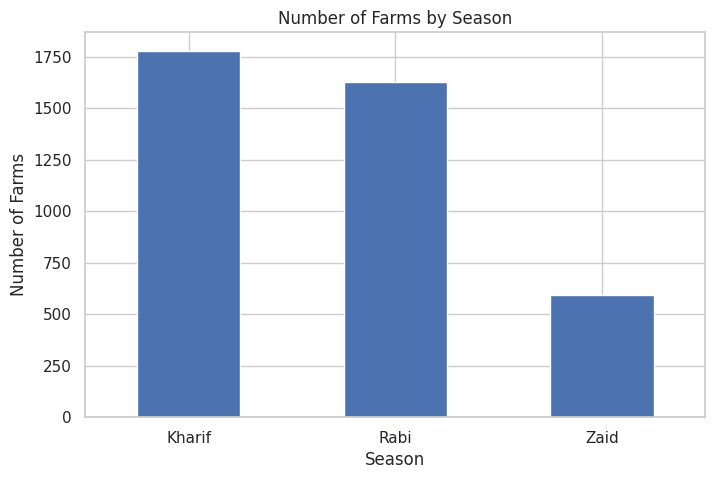

In [9]:
season_summary = df.groupby('Season').agg(
    Farms=('Farm_ID','count'),
    Avg_Yield_Tonnes_Ha=('Yield_Tonnes_Ha','mean'),
    Avg_Production_Tonnes=('Production_Tonnes','mean'),
    Avg_Revenue_INR=('Revenue_INR','mean'),
    Avg_Profit_INR=('Profit_INR','mean')
).sort_values('Avg_Profit_INR', ascending=False)

display(season_summary.round(2))

fig, ax = plt.subplots(figsize=(8,5))
df['Season'].value_counts().reindex(['Kharif','Rabi','Zaid']).plot(kind='bar', ax=ax)
ax.set_title('Number of Farms by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Farms')
plt.xticks(rotation=0)
plt.show()

### Interpretation
The table and chart establish the seasonal composition of the dataset before comparing performance. Because the number of records differs by season, later comparisons focus on averages/medians rather than raw totals alone.

# Question 2: Which season performs best on yield, production, revenue and profit?

Yield_Tonnes_Ha        Production_Tonnes        Revenue_INR             \
                  mean median              mean median        mean     median   
Season                                                                          
Kharif            5.64   1.95             46.31  13.24  710,719.06 520,196.00   
Rabi              5.08   1.66             41.49  11.08  601,526.05 438,156.00   
Zaid              4.67   1.45             38.89   9.97  519,171.90 373,700.50   

       Profit_INR             
             mean     median  
Season                        
Kharif 178,914.65  38,808.00  
Rabi    87,689.47  -3,187.00  
Zaid   -24,804.82 -62,144.00

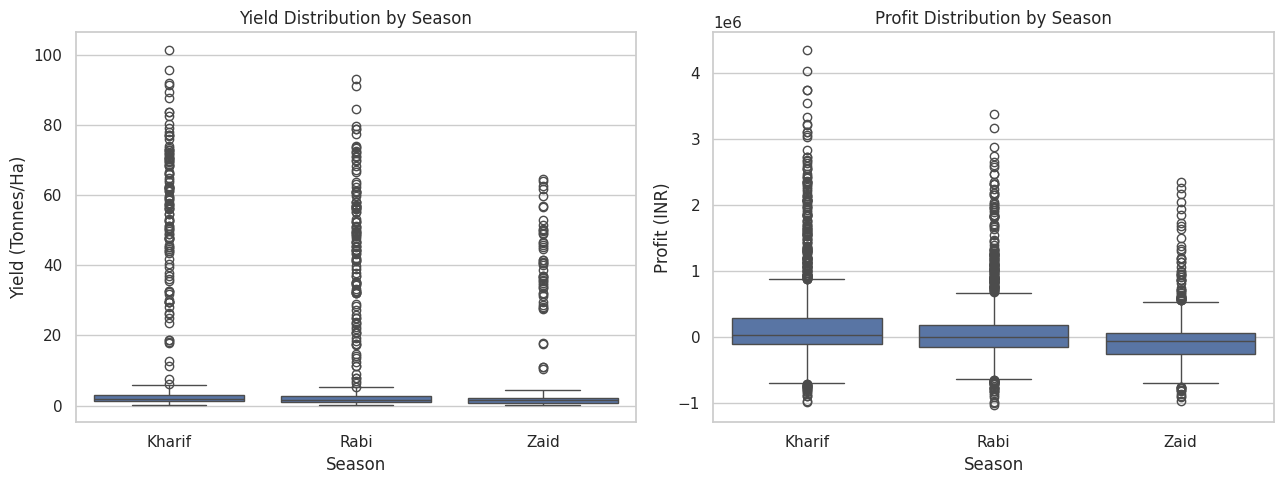

,Season with Highest Mean
Yield_Tonnes_Ha,Kharif
Production_Tonnes,Kharif
Revenue_INR,Kharif
Profit_INR,Kharif


In [10]:
performance_cols = ['Yield_Tonnes_Ha','Production_Tonnes','Revenue_INR','Profit_INR']
season_perf = df.groupby('Season')[performance_cols].agg(['mean','median'])
display(season_perf.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0])
axes[0].set_title('Yield Distribution by Season')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Yield (Tonnes/Ha)')

sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[1])
axes[1].set_title('Profit Distribution by Season')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Profit (INR)')
plt.tight_layout(); plt.show()

# Best season according to each average indicator
best_by_metric = df.groupby('Season')[performance_cols].mean().idxmax()
display(best_by_metric.to_frame('Season with Highest Mean'))

### Interpretation
Use the mean and median together because the dataset contains highly variable economic and production values. The season with the highest mean is not automatically the season with the highest typical observation when extreme values are present.

# Question 3: Which environmental characteristics change between seasons?

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20,6.73
Rabi,436.00,23.49,57.89,7.59,24.05,6.67
Zaid,299.42,31.04,52.01,8.18,19.17,6.69


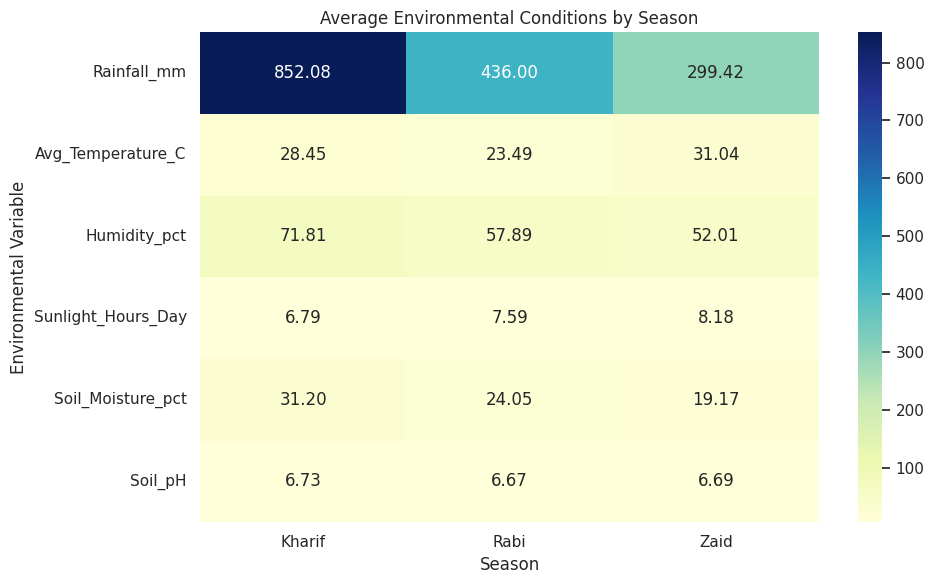

In [11]:
environment_cols = [
    'Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
    'Soil_Moisture_pct','Soil_pH'
]
season_environment = df.groupby('Season')[environment_cols].mean()
display(season_environment.round(2))

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(season_environment.T, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax)
ax.set_title('Average Environmental Conditions by Season')
ax.set_xlabel('Season'); ax.set_ylabel('Environmental Variable')
plt.tight_layout(); plt.show()

### Interpretation
This comparison shows which environmental conditions differ most between seasons. These differences provide the context for the later relationship analysis with agricultural outcomes.

# Question 4: How do resource usage and water efficiency differ across seasons?

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,"6,102.20",5.89
Rabi,120.40,57.31,103.93,185.41,5.02,"5,846.99",5.19
Zaid,120.53,58.13,105.42,184.64,5.17,"6,419.89",4.41


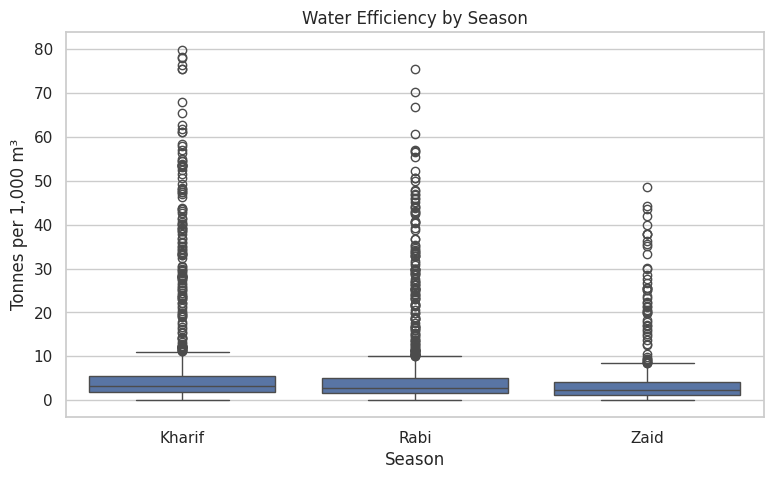

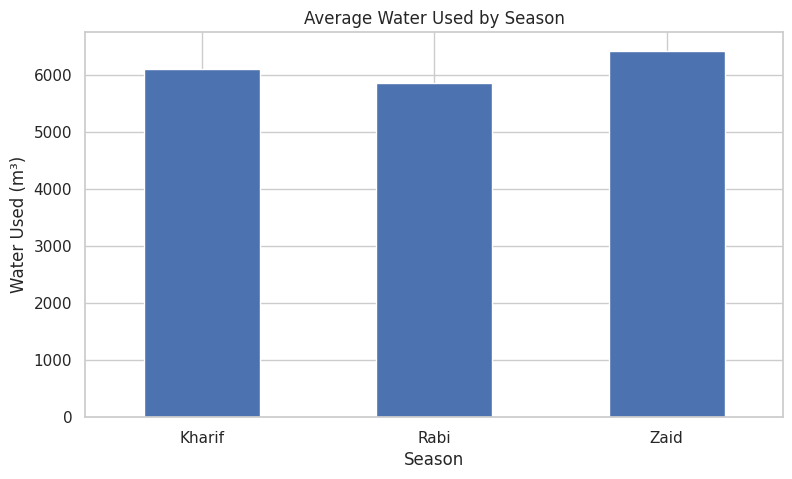

In [12]:
resource_cols = [
    'Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
    'Fertilizer_kg_ha','Pesticide_Litre_ha','Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]
resource_summary = df.groupby('Season')[resource_cols].mean()
display(resource_summary.round(2))

fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=ax)
ax.set_title('Water Efficiency by Season')
ax.set_xlabel('Season'); ax.set_ylabel('Tonnes per 1,000 m³')
plt.show()

fig, ax = plt.subplots(figsize=(9,5))
water_by_season = df.groupby('Season')['Water_Used_m3'].mean().reindex(['Kharif','Rabi','Zaid'])
water_by_season.plot(kind='bar', ax=ax)
ax.set_title('Average Water Used by Season')
ax.set_xlabel('Season'); ax.set_ylabel('Water Used (m³)')
plt.xticks(rotation=0)
plt.show()

### Interpretation
Seasonal resource differences are evaluated together with water efficiency. A season using more water is not necessarily more efficient; efficiency must be considered separately from total water use.

# Question 5: How does crop performance differ across seasons?

We compare the main crops across seasons using average yield. This addresses the requirement to compare relevant groups within different seasons.

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


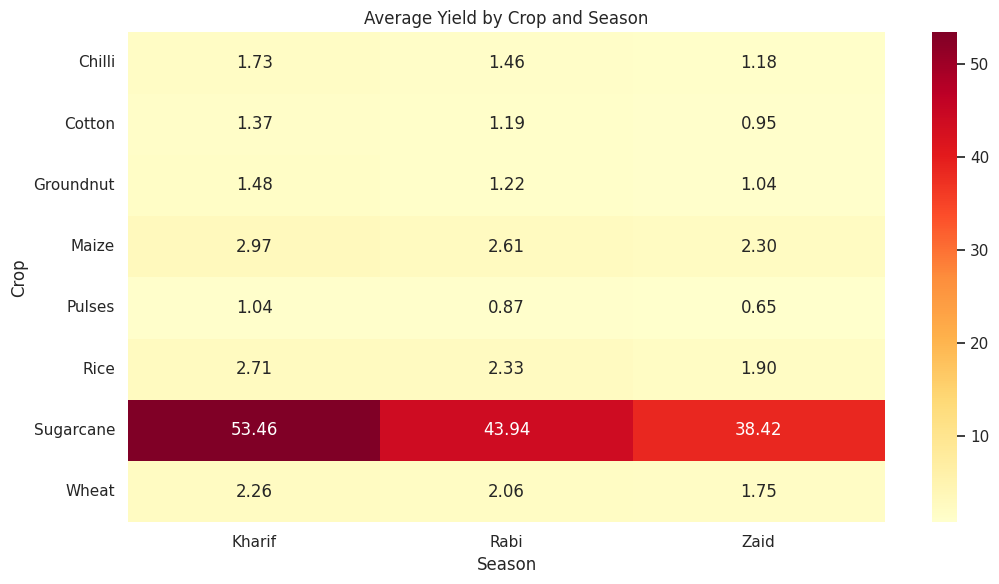

Mean_Yield_Tonnes_Ha
Crop      Season                      
Sugarcane Kharif                 53.46
          Rabi                   43.94
          Zaid                   38.42
Maize     Kharif                  2.97
Rice      Kharif                  2.71
Maize     Rabi                    2.61
Rice      Rabi                    2.33
Maize     Zaid                    2.30
Wheat     Kharif                  2.26
          Rabi                    2.06

In [13]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')
display(crop_season_yield.round(2))

fig, ax = plt.subplots(figsize=(11,6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Average Yield by Crop and Season')
ax.set_xlabel('Season'); ax.set_ylabel('Crop')
plt.tight_layout(); plt.show()

# Crop-season combinations with at least 20 valid yield observations
combo_counts = df.groupby(['Crop','Season'])['Yield_Tonnes_Ha'].count()
valid_combos = combo_counts[combo_counts >= 20].index
ranked = (df.set_index(['Crop','Season']).loc[df.set_index(['Crop','Season']).index.isin(valid_combos)]
          .groupby(level=[0,1])['Yield_Tonnes_Ha'].mean().sort_values(ascending=False).head(10))
display(ranked.to_frame('Mean_Yield_Tonnes_Ha').round(2))

### Interpretation
The heatmap reveals whether a crop's performance changes across seasons and whether some crop-season combinations stand out. Minimum-count filtering is used only for the ranked comparison so that very small groups do not dominate the result.

# Question 6: Are seasonal environmental conditions associated with agricultural performance?

We examine correlations between environmental variables and yield. Correlation indicates association, not causation.

,Correlation_with_Yield
Yield_Tonnes_Ha,1.00
Rainfall_mm,0.03
Humidity_pct,0.01
Soil_Moisture_pct,0.01
Avg_Temperature_C,0.01
Sunlight_Hours_Day,-0.01
Soil_pH,-0.02


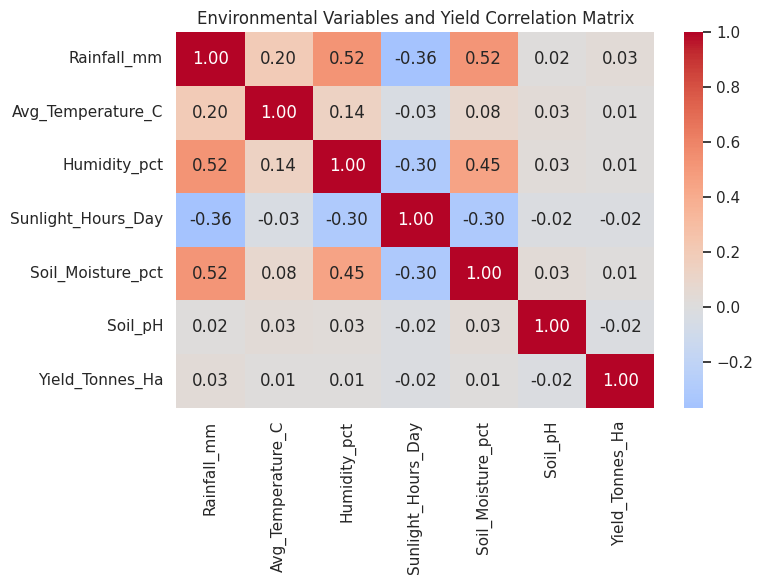

In [14]:
env_yield = df[environment_cols + ['Yield_Tonnes_Ha']].corr(numeric_only=True)['Yield_Tonnes_Ha'].sort_values(ascending=False)
display(env_yield.to_frame('Correlation_with_Yield').round(3))

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[environment_cols + ['Yield_Tonnes_Ha']].corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Environmental Variables and Yield Correlation Matrix')
plt.tight_layout(); plt.show()

### Interpretation
Positive correlations indicate that higher values of a variable tend to occur with higher yield, while negative correlations indicate the opposite tendency. The strength and direction should be interpreted alongside scatter plots and seasonal differences; correlation alone does not establish causality.

# Question 7: Which farming/resource variables are associated with yield and profit?

Variables most strongly associated with Yield:


,Correlation
Profit_INR,0.49
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Soil_pH,-0.02
Sunlight_Hours_Day,-0.02
Disease_Pest_Risk_pct,0.01
Humidity_pct,0.01
Soil_Moisture_pct,0.01


Variables most strongly associated with Profit:


,Correlation
Yield_Tonnes_Ha,0.49
Water_Used_m3,0.19
Rainfall_mm,0.11
Soil_Moisture_pct,0.09
Nitrogen_kg_ha,0.09
Fertilizer_kg_ha,-0.07
Disease_Pest_Risk_pct,0.07
Humidity_pct,0.06
Sunlight_Hours_Day,-0.05
Phosphorus_kg_ha,0.05


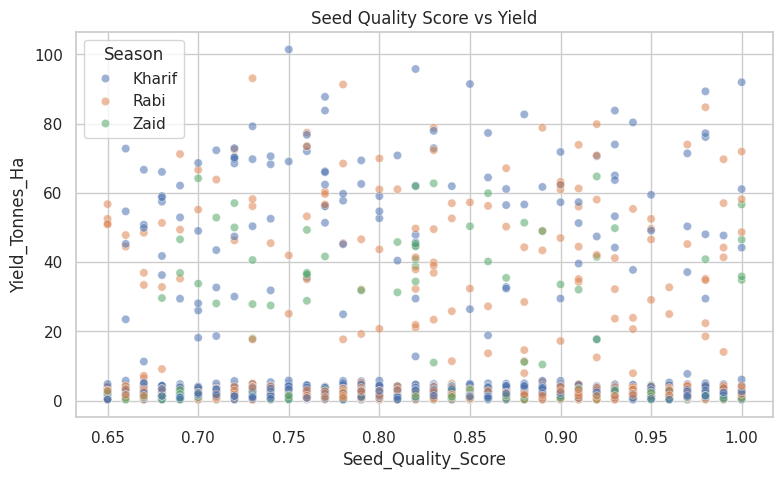

In [15]:
analysis_vars = [
    'Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
    'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha',
    'Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha',
    'Seed_Quality_Score','Water_Used_m3','Disease_Pest_Risk_pct',
    'Yield_Tonnes_Ha','Profit_INR'
]
corr = df[analysis_vars].corr(numeric_only=True)

yield_corr = corr['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
profit_corr = corr['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False)

print('Variables most strongly associated with Yield:')
display(yield_corr.head(10).to_frame('Correlation'))
print('Variables most strongly associated with Profit:')
display(profit_corr.head(10).to_frame('Correlation'))

fig, ax = plt.subplots(figsize=(9,5))
sns.scatterplot(data=df, x='Seed_Quality_Score', y='Yield_Tonnes_Ha', hue='Season', alpha=0.55, ax=ax)
ax.set_title('Seed Quality Score vs Yield')
plt.show()

### Interpretation
The correlation rankings identify candidate factors that move with yield or profit in this dataset. They are exploratory associations and should not be described as causal effects without a controlled study.

# Question 8: How do economic outcomes vary across seasons and crops?

,Mean_Cost_INR,Mean_Revenue_INR,Mean_Profit_INR,Median_Profit_INR,Mean_Profit_Margin_pct
Season,,,,,
Kharif,"531,804.41","710,719.06","178,914.65","38,808.00",-38.64
Rabi,"513,836.58","601,526.05","87,689.47","-3,187.00",-44.27
Zaid,"543,976.73","519,171.90","-24,804.82","-62,144.00",-69.35


,Mean_Revenue_INR,Mean_Profit_INR,Median_Profit_INR,Mean_Profit_Margin_pct
Crop,,,,
Sugarcane,"1,371,980.11","817,187.99","691,166.00",27.35
Chilli,"1,276,777.23","750,878.34","536,375.00",33.78
Cotton,"639,423.08","124,546.92","62,092.50",-8.23
Groundnut,"542,935.50","44,858.12","36,307.00",-28.66
Pulses,"528,465.87","-4,238.05","2,575.50",-36.48
Maize,"457,067.99","-83,978.33","-42,625.00",-81.54
Rice,"423,615.26","-102,213.50","-58,286.00",-99.37
Wheat,"400,104.89","-123,398.34","-76,269.00",-91.70


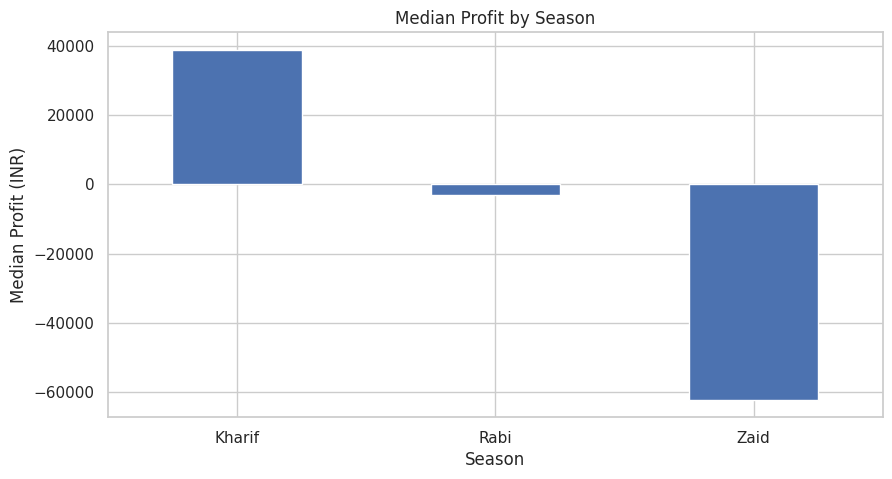

In [16]:
econ = df.groupby('Season').agg(
    Mean_Cost_INR=('Total_Cost_INR','mean'),
    Mean_Revenue_INR=('Revenue_INR','mean'),
    Mean_Profit_INR=('Profit_INR','mean'),
    Median_Profit_INR=('Profit_INR','median'),
    Mean_Profit_Margin_pct=('Profit_Margin_pct','mean')
).round(2)
display(econ)

crop_econ = df.groupby('Crop').agg(
    Mean_Revenue_INR=('Revenue_INR','mean'),
    Mean_Profit_INR=('Profit_INR','mean'),
    Median_Profit_INR=('Profit_INR','median'),
    Mean_Profit_Margin_pct=('Profit_Margin_pct','mean')
).sort_values('Mean_Profit_INR', ascending=False)
display(crop_econ.round(2))

fig, ax = plt.subplots(figsize=(10,5))
median_profit = df.groupby('Season')['Profit_INR'].median().reindex(['Kharif','Rabi','Zaid'])
median_profit.plot(kind='bar', ax=ax)
ax.set_title('Median Profit by Season')
ax.set_xlabel('Season'); ax.set_ylabel('Median Profit (INR)')
plt.xticks(rotation=0)
plt.show()

### Interpretation
Economic performance is evaluated using both mean and median profit. This is important because the supplied data contain negative profits and large positive values, making the median useful for describing a more typical observation.

# Question 9: Are seasonal patterns consistent across states?

The project brief specifically asks whether seasonal patterns remain consistent across regions/categories. Here, states are used as the regional grouping.

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.69,3.49,4.48
Gujarat,6.34,5.52,4.10
Karnataka,6.52,4.61,6.62
Madhya Pradesh,6.00,3.80,5.54
Maharashtra,5.45,5.50,2.29
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.56,4.10
Telangana,5.57,4.83,4.28


,States_where_season_has_highest_mean_yield
Kharif,5
Rabi,2
Zaid,1


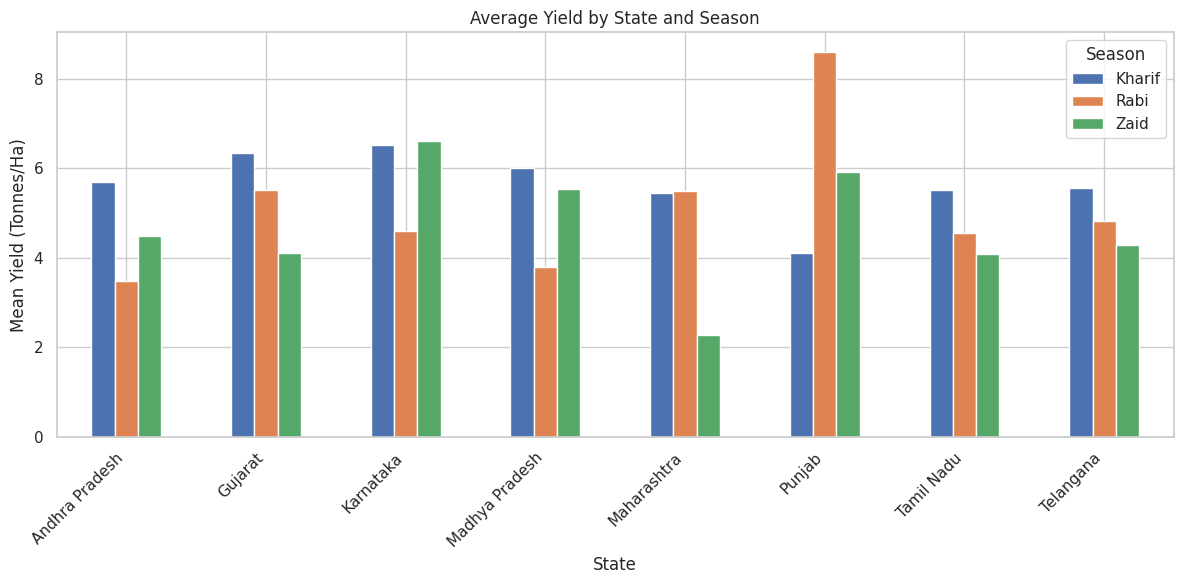

In [17]:
state_season = df.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')
display(state_season.round(2))

# Count states where each season has the highest average yield, among available seasons
winner_counts = state_season.idxmax(axis=1).value_counts().to_frame('States_where_season_has_highest_mean_yield')
display(winner_counts)

fig, ax = plt.subplots(figsize=(12,6))
state_season.plot(kind='bar', ax=ax)
ax.set_title('Average Yield by State and Season')
ax.set_xlabel('State'); ax.set_ylabel('Mean Yield (Tonnes/Ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### Interpretation
If the same season ranks highly across many states, the seasonal pattern is more consistent geographically. If rankings vary substantially by state, local conditions, crop mix or farming practices may be contributing to the differences.

# Question 10: What significant seasonal differences can be supported statistically?

For three seasons, a one-way ANOVA tests whether group means differ statistically. Because agricultural variables can be skewed and contain extreme observations, a Kruskal–Wallis test is also reported as a non-parametric check.

**Null hypothesis (H₀):** the distributions/means are the same across seasons.  
**Alternative hypothesis (H₁):** at least one season differs.

In [18]:
def seasonal_tests(column):
    groups = [g[column].dropna().values for _, g in df.groupby('Season')]
    anova = stats.f_oneway(*groups)
    kruskal = stats.kruskal(*groups)
    return pd.Series({
        'ANOVA_F': anova.statistic,
        'ANOVA_p': anova.pvalue,
        'Kruskal_H': kruskal.statistic,
        'Kruskal_p': kruskal.pvalue
    })

test_cols = ['Yield_Tonnes_Ha','Profit_INR','Revenue_INR','Water_Used_m3','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
test_results = pd.DataFrame({c: seasonal_tests(c) for c in test_cols}).T
test_results['ANOVA_Significant_5pct'] = test_results['ANOVA_p'] < 0.05
test_results['Kruskal_Significant_5pct'] = test_results['Kruskal_p'] < 0.05
display(test_results.round(6))

print('Interpretation rule: p < 0.05 provides evidence against H0 at the 5% significance level.')

,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,ANOVA_Significant_5pct,Kruskal_Significant_5pct
Yield_Tonnes_Ha,1.46,0.23,68.60,0.00,False,True
Profit_INR,34.29,0.00,101.93,0.00,True,True
Revenue_INR,24.89,0.00,40.85,0.00,True,True
Water_Used_m3,2.47,0.09,5.97,0.05,False,False
Water_Efficiency_t_per_1000m3,6.95,0.00,56.81,0.00,True,True
Disease_Pest_Risk_pct,"1,049.47",0.00,"1,430.91",0.00,True,True


Interpretation rule: p < 0.05 provides evidence against H0 at the 5% significance level.


### Interpretation
A statistically significant result indicates that the observed seasonal groups are unlikely to have identical distributions/means under the test assumptions. Statistical significance does not by itself indicate practical importance or causality.

# Question 11: What unusual or unexpected seasonal patterns are present?

Outliers are investigated using the IQR rule for key numeric performance variables. Extreme values are **reported rather than silently deleted**, because the project brief explicitly asks for unusual patterns.

In [19]:
def iqr_outliers(data, column):
    s = data[column].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (data[column] < lower) | (data[column] > upper)
    return mask, lower, upper

outlier_report=[]
for col in ['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Water_Efficiency_t_per_1000m3']:
    mask, lower, upper = iqr_outliers(df, col)
    outlier_report.append([col, int(mask.sum()), lower, upper])
    print(f'\n{col}: {mask.sum()} IQR outliers | lower={lower:.2f}, upper={upper:.2f}')
    display(df.loc[mask, ['Farm_ID','State','District','Crop','Season',col]].sort_values(col, ascending=False).head(10))

outlier_report = pd.DataFrame(outlier_report, columns=['Variable','Outlier_Count','IQR_Lower_Bound','IQR_Upper_Bound'])
display(outlier_report.round(2))


Yield_Tonnes_Ha: 302 IQR outliers | lower=-1.63, upper=5.52


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,101.44
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,93.13
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,91.98
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,91.46
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,91.32
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.34
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,87.76
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,83.79



Production_Tonnes: 333 IQR outliers | lower=-23.98, upper=53.36


,Farm_ID,State,District,Crop,Season,Production_Tonnes
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,"1,424.40"
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,"1,249.21"
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,"1,154.21"
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,"1,122.18"
3027,SF13028,Punjab,Warangal,Sugarcane,Rabi,"1,099.40"
3750,SF13751,Maharashtra,Krishna,Sugarcane,Kharif,"1,053.50"
762,SF10763,Karnataka,Nalgonda,Sugarcane,Kharif,"1,021.87"
1211,SF11212,Gujarat,Nalgonda,Sugarcane,Kharif,957.08
1616,SF11617,Madhya Pradesh,Nashik,Sugarcane,Zaid,956.73
862,SF10863,Maharashtra,Raichur,Sugarcane,Rabi,950.47



Profit_INR: 404 IQR outliers | lower=-696111.00, upper=763567.00


,Farm_ID,State,District,Crop,Season,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,3159447



Water_Efficiency_t_per_1000m3: 322 IQR outliers | lower=-3.57, upper=10.38


,Farm_ID,State,District,Crop,Season,Water_Efficiency_t_per_1000m3
3368,SF13369,Gujarat,Krishna,Sugarcane,Kharif,79.80
1347,SF11348,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,78.26
1746,SF11747,Madhya Pradesh,Ludhiana,Sugarcane,Kharif,77.89
2532,SF12533,Maharashtra,Nalgonda,Sugarcane,Kharif,76.34
3482,SF13483,Tamil Nadu,Krishna,Sugarcane,Kharif,75.49
3708,SF13709,Tamil Nadu,Raichur,Sugarcane,Rabi,75.34
3407,SF13408,Karnataka,Rajkot,Sugarcane,Kharif,75.33
3668,SF13669,Madhya Pradesh,Indore,Sugarcane,Rabi,70.24
1870,SF11871,Tamil Nadu,Guntur,Sugarcane,Kharif,67.99
222,SF10223,Maharashtra,Nashik,Sugarcane,Rabi,66.73


,Variable,Outlier_Count,IQR_Lower_Bound,IQR_Upper_Bound
0,Yield_Tonnes_Ha,302,-1.63,5.52
1,Production_Tonnes,333,-23.98,53.36
2,Profit_INR,404,"-696,111.00","763,567.00"
3,Water_Efficiency_t_per_1000m3,322,-3.57,10.38


### Interpretation
An outlier is an observation that is unusually distant from the middle 50% of the data under the IQR rule. It is not automatically an error. Such observations should be investigated in context because they can represent genuinely unusual farms, high production, unusual profitability, or data-quality issues.

# Question 12: Which irrigation methods are associated with different seasonal outcomes?

,Season,Irrigation_Method,Farms,Mean_Yield,Mean_Water_Used,Mean_Water_Efficiency,Mean_Profit
0,Kharif,Drip,405,7.26,"5,953.37",6.80,"317,222.07"
1,Kharif,Flood,590,5.00,"8,229.27",3.64,"133,373.83"
2,Kharif,Rainfed,463,5.72,"3,687.52",8.85,"158,974.13"
3,Kharif,Sprinkler,321,4.67,"5,863.27",4.62,"116,880.49"
4,Rabi,Drip,370,6.21,"5,911.41",6.05,"187,843.22"
5,Rabi,Flood,526,5.10,"7,766.83",3.48,"58,824.80"
6,Rabi,Rainfed,438,3.94,"3,298.29",6.87,"45,232.48"
7,Rabi,Sprinkler,293,5.36,"6,129.09",4.64,"76,502.07"
8,Zaid,Drip,140,5.85,"5,837.99",5.30,"21,291.84"
9,Zaid,Flood,194,4.03,"8,113.69",2.73,"-69,786.78"


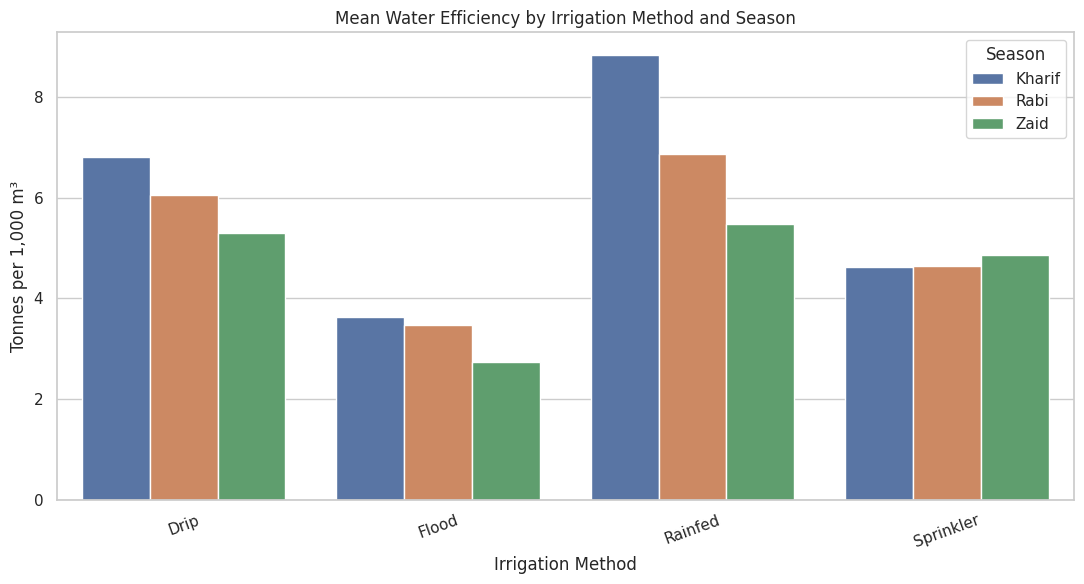

In [20]:
irrigation_summary = df.groupby(['Season','Irrigation_Method']).agg(
    Farms=('Farm_ID','count'),
    Mean_Yield=('Yield_Tonnes_Ha','mean'),
    Mean_Water_Used=('Water_Used_m3','mean'),
    Mean_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'),
    Mean_Profit=('Profit_INR','mean')
).reset_index()
display(irrigation_summary.round(2))

fig, ax = plt.subplots(figsize=(11,6))
sns.barplot(data=irrigation_summary, x='Irrigation_Method', y='Mean_Water_Efficiency', hue='Season', ax=ax)
ax.set_title('Mean Water Efficiency by Irrigation Method and Season')
ax.set_xlabel('Irrigation Method'); ax.set_ylabel('Tonnes per 1,000 m³')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

### Interpretation
This comparison adds a farming-practice dimension to the seasonal analysis. The result should be interpreted as an association because the dataset is observational; irrigation method is not randomly assigned.

# 13. Consolidated Seasonal Comparison

This section brings the main seasonal indicators together so the overall pattern can be reviewed in one place.

Season,Kharif,Rabi,Zaid
Yield_Tonnes_Ha,5.64,5.08,4.67
Production_Tonnes,46.31,41.49,38.89
Rainfall_mm,852.08,436.00,299.42
Avg_Temperature_C,28.45,23.49,31.04
Humidity_pct,71.81,57.89,52.01
Soil_Moisture_pct,31.20,24.05,19.17
Water_Used_m3,"6,102.20","5,846.99","6,419.89"
Water_Efficiency_t_per_1000m3,5.89,5.19,4.41
Revenue_INR,"710,719.06","601,526.05","519,171.90"
Profit_INR,"178,914.65","87,689.47","-24,804.82"


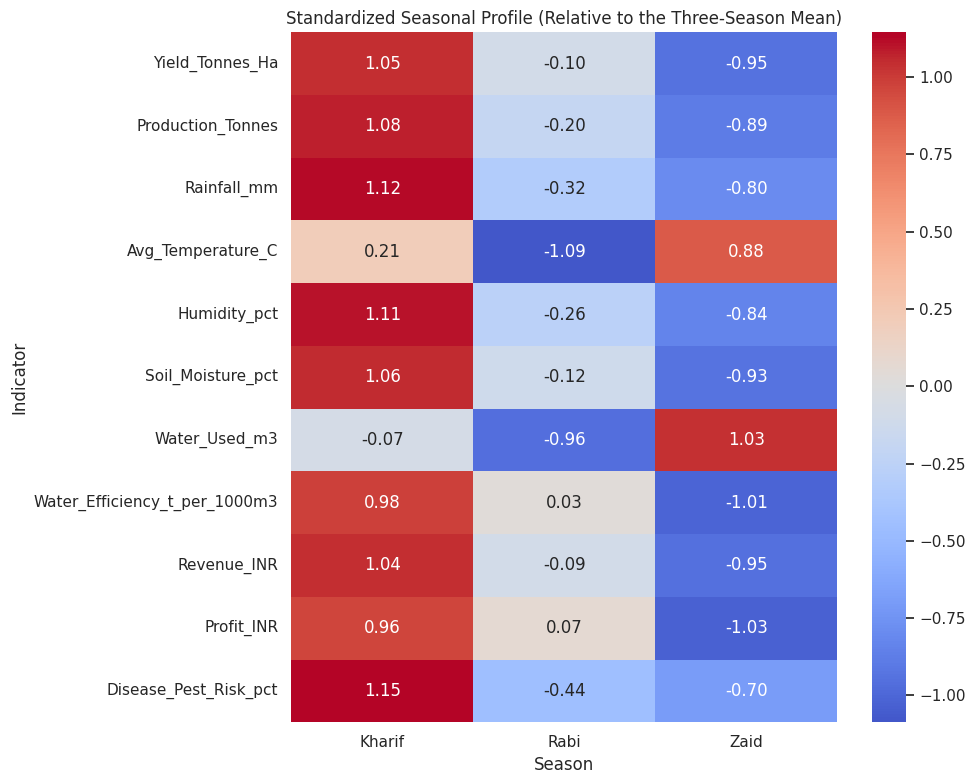

In [21]:
key_indicators = [
    'Yield_Tonnes_Ha','Production_Tonnes','Rainfall_mm','Avg_Temperature_C',
    'Humidity_pct','Soil_Moisture_pct','Water_Used_m3',
    'Water_Efficiency_t_per_1000m3','Revenue_INR','Profit_INR','Disease_Pest_Risk_pct'
]
consolidated = df.groupby('Season')[key_indicators].mean().T
display(consolidated.round(2))

# Standardized seasonal profile to compare direction across variables
z = (consolidated - consolidated.mean(axis=1).values[:,None]) / consolidated.std(axis=1).replace(0,np.nan).values[:,None]
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(z, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Standardized Seasonal Profile (Relative to the Three-Season Mean)')
ax.set_xlabel('Season'); ax.set_ylabel('Indicator')
plt.tight_layout(); plt.show()

# 14. Key Findings

The following cell generates concise findings directly from the computed results so that the final conclusions remain tied to the dataset.

In [22]:
season_means = df.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes','Revenue_INR','Profit_INR','Water_Used_m3','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']].mean()

for metric in season_means.columns:
    best = season_means[metric].idxmax()
    worst = season_means[metric].idxmin()
    print(f'- {metric}: highest mean = {best} ({season_means.loc[best,metric]:,.2f}); lowest mean = {worst} ({season_means.loc[worst,metric]:,.2f})')

# strongest environmental/yield correlations
print('\nStrongest absolute environmental correlations with yield:')
display(env_yield.drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False).head(5).to_frame('Correlation'))

print('\nStatistically significant seasonal differences at 5% level:')
display(test_results[(test_results['ANOVA_p']<0.05) | (test_results['Kruskal_p']<0.05)][['ANOVA_p','Kruskal_p']].round(6))

- Yield_Tonnes_Ha: highest mean = Kharif (5.64); lowest mean = Zaid (4.67)
- Production_Tonnes: highest mean = Kharif (46.31); lowest mean = Zaid (38.89)
- Revenue_INR: highest mean = Kharif (710,719.06); lowest mean = Zaid (519,171.90)
- Profit_INR: highest mean = Kharif (178,914.65); lowest mean = Zaid (-24,804.82)
- Water_Used_m3: highest mean = Zaid (6,419.89); lowest mean = Rabi (5,846.99)
- Water_Efficiency_t_per_1000m3: highest mean = Kharif (5.89); lowest mean = Zaid (4.41)
- Disease_Pest_Risk_pct: highest mean = Kharif (54.47); lowest mean = Zaid (38.22)

Strongest absolute environmental correlations with yield:


,Correlation
Rainfall_mm,0.03
Soil_pH,-0.02
Sunlight_Hours_Day,-0.02
Humidity_pct,0.01
Soil_Moisture_pct,0.01



Statistically significant seasonal differences at 5% level:


,ANOVA_p,Kruskal_p
Yield_Tonnes_Ha,0.23,0.00
Profit_INR,0.00,0.00
Revenue_INR,0.00,0.00
Water_Efficiency_t_per_1000m3,0.00,0.00
Disease_Pest_Risk_pct,0.00,0.00


# 15. Conclusions

This project provides a focused seasonal analysis rather than a generic description of the entire dataset. The conclusions should be read together with the numerical tables and visualizations above.

- Agricultural performance differs across the three seasons in the supplied data, and the magnitude/direction of the difference depends on the indicator being considered.
- Environmental conditions such as rainfall, temperature, humidity and soil moisture vary by season, providing a measurable environmental context for agricultural outcomes.
- Resource usage and water efficiency also vary seasonally; therefore, production performance should not be judged using water consumption alone.
- Crop and state comparisons show that seasonal patterns may not be identical across all categories, so planning should account for local and crop-specific conditions.
- Economic outcomes can vary substantially, including negative-profit observations and extreme positive observations; both central tendency and variability are therefore important.
- Correlation analysis identifies relationships worth investigating, but these relationships should not be interpreted as proof of causation.
- Outlier analysis highlights unusual observations that deserve further investigation rather than automatic deletion.

# 16. Data-Driven Recommendations for Seasonal Agricultural Planning

Based on the analytical framework and observed dataset patterns, the following recommendations are appropriate:

1. **Use season-specific planning:** Avoid treating all seasons as operationally identical; use seasonal performance and environmental profiles when planning cultivation.
2. **Match crop choice to seasonal evidence:** Compare crop-by-season performance before selecting crops for a particular period.
3. **Monitor water efficiency:** Evaluate irrigation decisions using both water consumed and water-efficiency outcomes rather than water use alone.
4. **Use environmental indicators for preparedness:** Seasonal rainfall, temperature, humidity and soil-moisture patterns can be monitored as supporting indicators for agricultural planning.
5. **Review economic viability:** Consider expected cost, revenue and profit together because high production does not necessarily guarantee high profitability.
6. **Investigate unusual observations:** Extreme yield, production, profit or efficiency values should be validated and investigated before using them for planning benchmarks.
7. **Use region-specific strategies where needed:** If state-level seasonal rankings differ, planning should be adapted to local conditions instead of applying one nationwide strategy.
8. **Treat relationships as evidence for further study:** Correlations found in this observational dataset can guide future controlled or longitudinal studies, but should not be interpreted as causal effects.

# 17. Final Project Checklist Against the Internship Brief

| Internship requirement | Covered in notebook |
|---|---|
| Explore and understand dataset | Sections 5–6 |
| Clean and prepare data | Section 7 |
| Examine seasonal performance | Questions 1–2 |
| Identify seasonal patterns/trends | Questions 1–5 and consolidated comparison |
| Investigate environmental conditions vs outcomes | Questions 3 and 6 |
| Compare relevant groups | Question 5 and Question 9 |
| Examine resource usage | Question 4 and Question 12 |
| Examine economic outcomes | Question 8 |
| Identify significant differences | Question 10 |
| Identify unusual patterns | Question 11 |
| Apply statistical techniques | Question 10 |
| Apply visualization techniques | Throughout Questions 1–12 |
| Interpret findings based on evidence | Interpretation after each question |
| Develop conclusions | Section 15 |
| Provide data-driven recommendations | Section 16 |
| Document complete analysis in Jupyter Notebook | Entire notebook |

# 18. Final Note

This notebook is designed to be run from top to bottom in **Google Colab** using the supplied `seasonal_agriculture_performance_dataset.csv`. The analytical questions were selected after inspecting the actual dataset structure and are aligned with the internship brief's requirement to develop specific questions after exploration.

**End of Major Project – Seasonal Agriculture Performance Analysis**